# Estruturas de Dados

## Arrays, Vetor, Vector ou List

- Estrutura de armazenamento e manipulação de dados mais simples.

- Na memória, um array ocupa um espaço contínuo de variáveis.

- Arrays possuem indices, ou seja, cada elemento pertence a uma posição específica, permitindo localizar e trocar elementos de posições.

- Em Python, Arrays tem o 1º elemento no indice 0.

- Python possui métodos como .append() e .pop() para facilitar a inserção/remoção do último elemento, assim como .insert() e .remove() para a inserção/remoção de elementos em posições aletórias.

- Termos e Métodos:

    - Acessar: consulta o elemento presente na posição informada dentro do vetor.

    - Buscar: encontra o elemento informado dentro do vetor. Sua eficiência muda de acordo com o grau de ordenação do vetor.

    - Remover: remove um elemento do vetor.

    - Inserção: insere o elemento, pode ser no fim ou em qualquer ponto.

    - Atualizar: substitui o valor de uma posição por outro.

In [ ]:
array = [7, 12, 9, 4, 11]

def ler_valor():
    return int(input('Digite um valor numérico: '))

def buscar(arr, num):
    for i in range(len(arr)):
        if arr[i] == num:
            return f'Valor encontrado no índice {i}'
    return 'Valor não encontrado'

def inserir_ordenado(arr, num):
    arr.append(num)          # coloca no final
    i = len(arr) - 1
    while i > 0 and arr[i-1] > arr[i]:   # "borbulha" pra posição certa
        arr[i], arr[i-1] = arr[i-1], arr[i]
        i -= 1
    return 'Valor inserido!'

def remover(arr, num):
    for i in range(len(arr)):
        if arr[i] == num:
            for j in range(i, len(arr) - 1):
                arr[j] = arr[j+1]   # desloca tudo uma posição pra trás
            arr.pop()                # remove o último (duplicado)
            return 'Valor removido!'
    return 'Valor não encontrado'

while True:
    print('1 - INSERIR VALOR')
    print('2 - BUSCAR VALOR')
    print('3 - REMOVER VALOR')

    opcao = int(input('Digite a opção: '))

    match opcao:
        case 1:
            print(inserir_ordenado(array, ler_valor()))
        case 2:
            print(buscar(array, ler_valor()))
        case 3:
            print(remover(array, ler_valor()))
        case _:
            print('Opção inválida')

    print('Array atual:', array)

### Complexidade

O tempo de execução do algoritmo é proporcional, ou linear, ao tamanho do conjunto de dados.

Se um array possui 1000 valores, o loop teria que ser executado 1000 vezes.


| Operação |  Complexidade |
|---|---|
| `acessar()` | O(1) |
| `buscar()` | O(n) |
| `buscar_ordenado()` | O(1) |
| `remover()` | O(n) |
| `inserir()` | O(n) |
| `inserirFim()` | O(1)* |
| `atualizar()` | O(1) |

- Remover e Inserir são O(n) pois implicam em reorganizar os elementos do vetor, seja para esquerda ou para direita em casos de remoção e inserção, respectivamente.

- Inserir no fim PODE se tornar O(n) caso não possua mais espaço vetor, obrigando o sistema realocar todos os elementos de um vetor para outro vetor na memória.


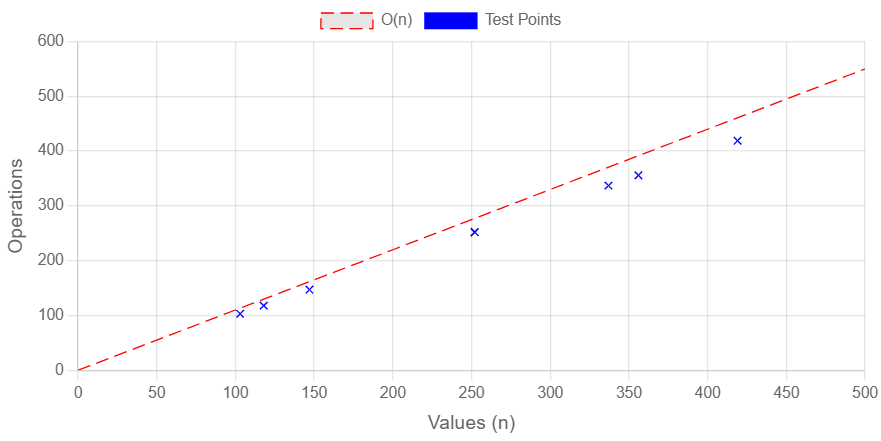

# Linked List (Listas Encadeadas)

- Estrutura de armazenamento e manipulação de dados construida a partir de Nodes e Ponteiros.

- Cada Node contêm um campo para 'Valor' e um ou dois campos para 'Ponteiros' a depender da aplicação.

- Cada Ponteiro pode apontar para o enderço de memória de outro Node, seja esse Node anterior ou próximo.

- Ao remover ou incluir um elemento, a única mudança é fazer a devida ligação entre os Nodes _anterior_ e _próximo_.

- Diferente da lista do Python (que é um array dinâmico), os elementos **não** ficam em posições contíguas de memória.

- Termos:

    - Head: Ponteiro que sempre apontará para o 1º elemento da lista.

    - Tail: Ponteiro que sempre apontará para o último elemento da lista.

    - insertStart(): Insere no começo.

    - insertEnd(): Insere no final.

    - remove(): remove a primeira ocorrência de X.

    - find(): verifica se X existe.

    - printList(): percorre e mostra todos os nós.

#### Singly linked list (lista encadeada simples)                

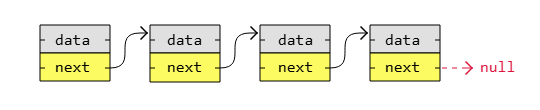

#### Doubly linked list (lista duplamente encadeada)

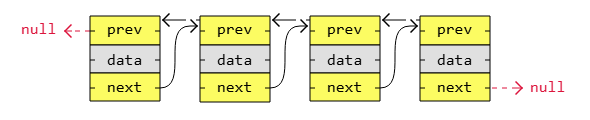

#### Circular linked list (lista circular (simples ou duplamente) encadeada)

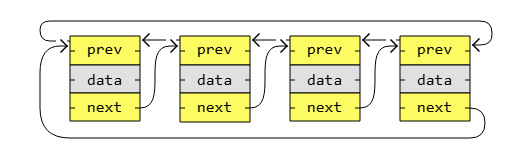

In [ ]:
class Node:
    """Um nó individual da lista ligada:
    guarda um valor e aponta para o próximo nó."""

    def __init__(self, valor):
        self.valor = valor
        self.proximo = None  # por padrão, não aponta para lugar nenhum


class ListaLigada:
    """Lista ligada simples (singly linked list)."""

    def __init__(self):
        self.head = None  # primeiro nó da lista (head)

    def inserir_inicio(self, valor):
        """Insere um novo nó no início da lista."""
        novo_node = Node(valor)
        novo_node.proximo = self.head
        self.head = novo_node

    def inserir_fim(self, valor):
        """Insere um novo nó no final da lista."""
        novo_node = Node(valor)

        if self.head is None:
            self.head = novo_node
            return
        atual = self.head

        while atual.proximo is not None:
            atual = atual.proximo
        atual.proximo = novo_node

    def remover(self, valor):
        """Remove a primeira ocorrência do valor. Retorna True se removeu, False se não achou. O(n)"""
        atual = self.head
        anterior = None

        while atual is not None:
            if atual.valor == valor:
                if anterior is None:       # o nó a remover é a cabeça
                    self.head = atual.proximo
                else:
                    anterior.proximo = atual.proximo
                return True
            anterior = atual
            atual = atual.proximo

        return False  # valor não encontrado

    def buscar(self, valor):
        """Retorna True se o valor existir na lista."""
        atual = self.head

        while atual is not None:
            if atual.valor == valor:
                return True
            atual = atual.proximo
        return False

    def __repr__(self):
        valores = []
        atual = self.head

        while atual is not None:
            valores.append(str(atual.valor))
            atual = atual.proximo
        return " -> ".join(valores) + " -> None"


# --- Demonstração ---
lista = ListaLigada()
lista.inserir_fim(10)
lista.inserir_fim(20)
lista.inserir_fim(30)
lista.inserir_inicio(5)
print(lista)                     # 5 -> 10 -> 20 -> 30 -> None

lista.remover(20)
print(lista)                     # 5 -> 10 -> 30 -> None

print("Contém 10?", lista.buscar(10))  # True
print("Contém 99?", lista.buscar(99))  # False

### Complexidade

São muito boas para alocação dinâmica (inserção em posições aleatórias) e alterações nas extremidades.

Sua complexidade pode ser reduzida quando implementamos ponteiros como *HEAD* e *TAIL*.

Perdem para Arrays quando se trata de buscar, inserir ou remover valores em posições "aleatórias".

| Operação | Complexidade |
|---|---|
| `insertStart()` | O(1) |
| `insertEnd()` | O(1) |
| `insertEnd()` | O(n) |    
| `remove()` | O(n) |
| `find()` | O(n) |
| `printList()` | O(n) |


- insertEnd():  O(1) = Usa Tail.
- insertEnd():  O(n) = Sem Tail, percorremos a lista até o fim. 

# Queue (Fila)

- Estrutura que usa o conceito de `FIFO` (First In, First Out - O primeiro a entrar é o primeiro a sair).

- Pode ser implementada usando Arrays ou Linked Lists

- Termos: 

    - Enqueue: insere um elemento no final da fila.

    - Dequeue: remove o elemento que está no início da fila.

    - Peek/Front: retorna o valor do próximo elemento a sair, sem removê-lo.

    - isEmpty: verifica se a fila está vazia (sem elementos).

    - Size: retorna o número total de elementos presentes na fila.

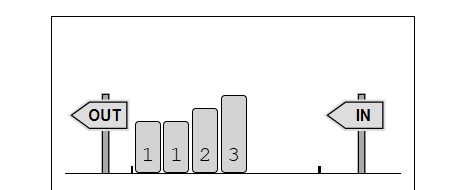

In [ ]:
class Fila:
    """Implementação da Fila usando listas do Python.
    """

    def __init__(self):
        self._itens = []

    def enqueue(self, item):
        """Insere um item no final da fila."""
        self._itens.append(item)

    def dequeue(self):
        """Remove e retorna o item do início da fila."""
        if self.is_empty():
            raise IndexError("dequeue(): a fila está vazia")
        return self._itens.pop(0)

    def peek(self):
        """Retorna o item do início sem removê-lo."""
        if self.is_empty():
            raise IndexError("peek(): a fila está vazia")
        return self._itens[0]

    def is_empty(self):
        return len(self._itens) == 0

    def size(self):
        return len(self._itens)

    def __repr__(self):
        return f"Fila(início -> fim): {self._itens}"
    
    # --- Demonstração ---
fila = Fila()
fila.enqueue("A")
fila.enqueue("B")
fila.enqueue("C")
print(fila)                         # Fila(início -> fim): ['A', 'B', 'C']
print("Início:", fila.peek())       # A
print("Removido:", fila.dequeue())  # A
print(fila)                         # Fila(início -> fim): ['B', 'C']


### Complexidade

Apenas as extremidades sofrem com inserções ou remoções.

| Operação | Complexidade |
|---|---|
| `enqueue()` |  O(1) |
| `dequeue()` | O(1) |
| `peek()` | O(1) |
| `is_empty()` | O(1) |
| `size()` | O(1)* |

- Size() pode variar sua notação a depender se o tamanho do vetor está sendo armazenado em uma variável.

# Stack (Pilha)

- Estrutura que usa o conceito de `LIFO` (Last In, First Out - O último a entrar é o primeiro a sair).

- Pode ser implementada usando Arrays ou Linked Lists

- Termos: 

    - Push: insere um elemento no topo da pilha.

    - Pop: remove o elemento que está no topo da pilha.

    - Peek: retorna o valor do próximo elemento a sair, do topo, sem removê-lo.

    - isEmpty: verifica se a pilha está vazia (sem elementos).

    - Size: retorna o número total de elementos presentes na fila.

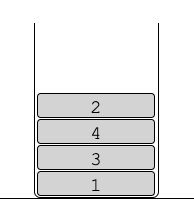

In [ ]:
class Pilha:
    """Implementação de uma Pilha (Stack) usando uma lista Python como armazenamento interno."""

    def __init__(self):
        self._itens = []  # lista interna que guarda os elementos

    def push(self, item):
        """Insere um item no topo da pilha."""
        self._itens.append(item)

    def pop(self):
        """Remove e retorna o item do topo."""
        if self.is_empty():
            raise IndexError("pop(): a pilha está vazia")
        return self._itens.pop()

    def peek(self):
        """Retorna o item do topo sem removê-lo."""
        if self.is_empty():
            raise IndexError("peek(): a pilha está vazia")
        return self._itens[-1]

    def is_empty(self):
        """Retorna True se a pilha estiver vazia."""
        return len(self._itens) == 0

    def size(self):
        """Retorna a quantidade de elementos na pilha."""
        return len(self._itens)

    def __repr__(self):
        # topo à direita, para visualizar como uma pilha "de baixo para cima"
        return f"Pilha(base -> topo): {self._itens}"


# --- Demonstração ---
pilha = Pilha()
pilha.push(1)
pilha.push(2)
pilha.push(3)
print(pilha)                 # Pilha(base -> topo): [1, 2, 3]
print("Topo:", pilha.peek()) # 3
print("Removido:", pilha.pop())  # 3
print(pilha)                 # Pilha(base -> topo): [1, 2]
print("Vazia?", pilha.is_empty())
print("Tamanho:", pilha.size())

### Complexidade

- Apenas uma das extremidades sofrem com inserções ou remoções.

| Operação | Complexidade |
|---|---|
| `enqueue()` |  O(1) |
| `dequeue()` | O(1) |
| `peek()` | O(1) |
| `is_empty()` | O(1) |
| `size()` | O(1)* |

- Size() pode variar sua notação a depender se o tamanho do vetor está sendo armazenado em uma variável.

# Hash Table / Hash Map

Uma estrutura de dados que armazena pares **chave-valor**, permitindo que as operações sejam realizadas em tempo médio de O(1). Isso ocorre por causa da **função hash**, que transforma a entrada de dados em um indice de um array préviamente criado.
Uma mesma entrada deve gerar sempre um mesmo Hash.
Entradas diferentes que por coincidência gerem o mesmo valor hash irão gerar **Colisões**. Tais colisões podem ser tratadas com Linked Lists.

Exemplo: se eu quero guardar o preço da maçã, que é R$3, a função hash pega "maçã", calcula um número (ex: 47), aplica módulo pelo tamanho do array (ex: 47 % 10 = 7), e guarda o preço no índice 7.

A Hash Table consiste em 4 etapas:
    - Iniciar um array. 
    - Criar uma função hash.
    - Entrar com dados que serão transformados pela hash function.
    - Lidar com colisões

- Termos:

    - Bucket (Balde): Espaço de armazenamento dentro da Hash Table, o indice gerado pela função representa um bucket.

    - Collision (Colisão): Evento que ocorre quando duas entradas de dados diferentes produzem o mesmo código hash e consequentemente seriam armazenadas no mesmo **Bucket**. Devem ser tratadas pois matemáticamente são inevitávelmente, pois a entrada de dados é superior a quantidade de indices de um vetor.

    - Key:Value (Chave:Valor): A **chave** é entrada da função hash, o **valor** é o que desejamos armazenar na posição correspondente ao resultado da função.

    - Chaining (Encadeamento): Forma que tratamos colisões, pode ser com **arrays internos e dinâmicos** ou **linked lists**

In [ ]:
class TabelaHash:
    """Tabela hash com tratamento de colisão por encadeamento separado (separate chaining)."""

    def __init__(self, capacidade=8):
        self.capacidade = capacidade
        # cada posição (bucket) começa como uma lista vazia de pares [chave, valor]
        self._buckets = [[] for _ in range(capacidade)]
        self._quantidade = 0

    def _hash(self, chave):
        """Converte a chave em um índice válido dentro da capacidade da tabela."""
        return hash(chave) % self.capacidade

    def inserir(self, chave, valor):
        """Insere um par chave-valor. Se a chave já existir, atualiza o valor. O(1) em média."""
        indice = self._hash(chave)
        bucket = self._buckets[indice]

        for par in bucket:
            if par[0] == chave:
                par[1] = valor  # chave já existe: atualiza o valor
                return

        bucket.append([chave, valor])  # chave nova: adiciona ao bucket
        self._quantidade += 1

    def buscar(self, chave):
        """Retorna o valor associado à chave. Lança KeyError se não existir. O(1) em média."""
        indice = self._hash(chave)
        bucket = self._buckets[indice]

        for par in bucket:
            if par[0] == chave:
                return par[1]

        raise KeyError(f"chave não encontrada: {chave!r}")

    def remover(self, chave):
        """Remove o par associado à chave. Retorna True se removeu, False se não existia."""
        indice = self._hash(chave)
        bucket = self._buckets[indice]

        for i, par in enumerate(bucket):
            if par[0] == chave:
                bucket.pop(i)
                self._quantidade -= 1
                return True

        return False

    def contem(self, chave):
        """Retorna True se a chave existir na tabela. O(1) em média."""
        indice = self._hash(chave)
        return any(par[0] == chave for par in self._buckets[indice])

    def __len__(self):
        return self._quantidade

    def __repr__(self):
        pares = []
        for bucket in self._buckets:
            for chave, valor in bucket:
                pares.append(f"{chave!r}: {valor!r}")
        return "{" + ", ".join(pares) + "}"
    
    # --- Demonstração ---
tabela = TabelaHash()
tabela.inserir("nome", "Gabriel")
tabela.inserir("curso", "Estrutura de Dados")
tabela.inserir("linguagem", "Python")

print(tabela)                          # {'nome': 'Gabriel', 'curso': 'Estrutura de Dados', 'linguagem': 'Python'}
print("Busca:", tabela.buscar("nome")) # Gabriel

tabela.inserir("nome", "Gabriel Silva")  # atualiza valor existente
print("Após atualizar:", tabela.buscar("nome"))

print("Contém 'curso'?", tabela.contem("curso"))  # True
tabela.remover("curso")
print("Após remover:", tabela)
print("Quantidade de itens:", len(tabela))

### Complexidade

- Apenas uma das extremidades sofrem com inserções ou remoções.

| Operação | Complexidade (médio) | Complexidade (pior caso) |
|---|---|---|
| `buscar()` | O(1) | O(n) |
| `inserir()` | O(1) | O(n) |
| `remover()` | O(1) | O(n) |
| `encadeamento()` | O(n) | O(n) |

- Todas tem pior caso O(n) pois implica em percorrer um vetor/linked list para encontrar o elemento específico e remove-lo